#**EXAMEN PARCIAL 1 - EJ 1 PYTHON**
##Julieta Madrigal Flores
###744029
###Martes 03 de marzo del 2026

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt

#1. Descarga y preparación de datos

In [5]:
stocks = ["AAPL", "MSFT", "JNJ"]

# Convert the end date string to a datetime object
end   = dt.datetime.strptime('28-02-2026', '%d-%m-%Y')
# Descarga precios de cierre de los últimos 4 años
start = end - dt.timedelta(days=365 * 4)

prices = yf.download(stocks, start=start, end=end, progress=False)["Close"]
prices = prices.dropna()
prices.tail()

/tmp/ipython-input-603/1206777631.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(stocks, start=start, end=end, progress=False)["Close"]


Ticker,AAPL,JNJ,MSFT
Date,,,
2026-02-23,266.179993,244.539993,384.470001
2026-02-24,272.140015,246.279999,389.000000
2026-02-25,274.230011,245.169998,400.600006
2026-02-26,272.950012,243.470001,401.720001
2026-02-27,264.179993,248.429993,392.739990


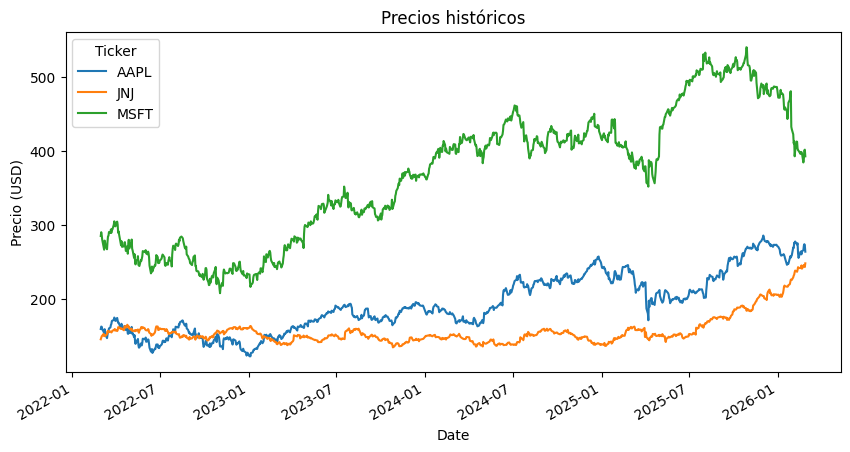

In [6]:
prices.plot(figsize=(10, 5), title="Precios históricos")
plt.ylabel("Precio (USD)")
plt.show()

#2. Rendimientos, medias y covarianzas



In [7]:
returns = prices.pct_change().dropna()

# media
mu    = returns.mean().values
# desviación estándar
sigma = returns.std().values
# matriz de covarianza
cov   = returns.cov()

print("Rendimiento promedio diario:")
print(returns.mean())
print("\nMatriz de covarianzas:")
print(cov)

Rendimiento promedio diario:
Ticker
AAPL    0.000661
JNJ     0.000589
MSFT    0.000464
dtype: float64

Matriz de covarianzas:
Ticker      AAPL       JNJ      MSFT
Ticker                              
AAPL    0.000322  0.000028  0.000180
JNJ     0.000028  0.000117  0.000007
MSFT    0.000180  0.000007  0.000290


#3. Simulación de 10,000 portafolios

In [8]:
# Fijamos una semilla aleatoria para que cada vez que corramos el código nos de exactamente los mismos resultados
np.random.seed(42)

# Cuenta cuántos activos tienes
n_assets     = len(stocks)
# portafolios vamos a simular
n_portfolios = 10000
# número de escenarios
n_sim = 5000
# tasa libre de riesgo anual del 4% convertida a diaria
RF= 0.04 / 252

# tabla donde guardamos los rendimientos simulados
sim_returns = np.zeros((n_sim, n_assets))

#Para cada activo generamos 5,000 escenarios de rendimientos aleatorios con distribución normal
# considerando la media y volatilidad  históricas de ese activo
for i in range(n_assets):
    sim_returns[:, i] = np.random.normal(mu[i], sigma[i], n_sim)

#4. Cálculos por portafolio



In [9]:
# lista vacía donde vas a guardamos los resultados de cada portafolio
results = []

for _ in range(n_portfolios):
    # Generas 3 pesos aleatorios y los divides entre su suma para que sumen exactamente 1
    w = np.random.random(n_assets)
    w = w / w.sum()

    # Multiplicas los rendimientos simulados por los pesos del portafolio
    #  @ es multiplicación matricial = rendimiento combinado del portafolio en cada uno de los 5,000 escenarios
    port_returns = sim_returns @ w

    # rendimiento esperado promedio y el riesgo de ese portafolio en los 5,000 escenarios
    mean_ret = np.mean(port_returns)
    std_dev  = np.std(port_returns)

    # if std_dev > 0 else 0 es para evitar una división entre cero en caso de que algún portafolio tenga riesgo nulo
    sharpe   = (mean_ret - RF) / std_dev if std_dev > 0 else 0

    # Guardas los pesos y las tres métricas de ese portafolio en la lista
    results.append([w, mean_ret, std_dev, sharpe])

results_df = pd.DataFrame(results, columns=["Weights", "Mean", "Desv", "Sharpe"])
results_df.head()

,Weights,Mean,Desv,Sharpe
0,"[0.2990042183876317, 0.01159457148897134, 0.68...",0.000677,0.012878,0.040255
1,"[0.36683044730982833, 0.5914749913304898, 0.04...",0.000591,0.009219,0.046925
2,"[0.2603896998868037, 0.2969332637638549, 0.442...",0.000626,0.009402,0.049746
3,"[0.575912181048151, 0.2772857299991708, 0.1468...",0.000667,0.010999,0.046187
4,"[0.07184981898427795, 0.08788190261298778, 0.8...",0.000638,0.014380,0.033332


In [10]:
idx_min_risk   = results_df["Desv"].idxmin()
idx_max_return = results_df["Mean"].idxmax()
idx_max_sharpe = results_df["Sharpe"].idxmax()

port_min_risk   = results_df.loc[idx_min_risk].copy()
port_max_return = results_df.loc[idx_max_return].copy()
port_max_sharpe = results_df.loc[idx_max_sharpe].copy()

port_min_risk["Weights"]   = port_min_risk["Weights"].round(3)
port_max_return["Weights"] = port_max_return["Weights"].round(3)
port_max_sharpe["Weights"] = port_max_sharpe["Weights"].round(3)

print("Portafolio de menor riesgo:")
print(port_min_risk)

print("\nPortafolio de mayor rendimiento:")
print(port_max_return)

print("\nPortafolio de mayor Sharpe:")
print(port_max_sharpe)

Portafolio de menor riesgo:
Weights    [0.21, 0.56, 0.23]
Mean                 0.000578
Desv                 0.008147
Sharpe               0.051462
Name: 2385, dtype: object

Portafolio de mayor rendimiento:
Weights    [0.986, 0.013, 0.002]
Mean                    0.000758
Desv                    0.017613
Sharpe                  0.034014
Name: 1455, dtype: object

Portafolio de mayor Sharpe:
Weights    [0.301, 0.435, 0.264]
Mean                    0.000609
Desv                     0.00844
Sharpe                   0.05334
Name: 8683, dtype: object


#5. Gráfica riesgo rendimiento

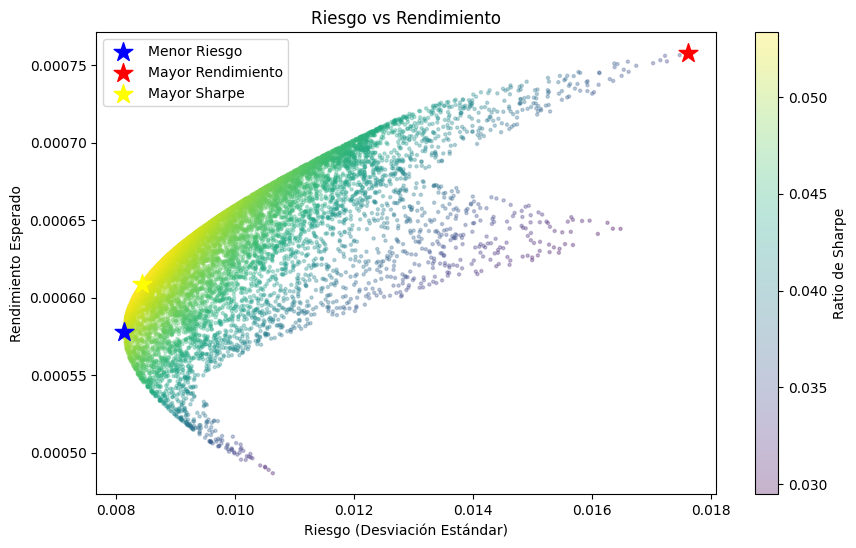

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(results_df["Desv"], results_df["Mean"], c=results_df["Sharpe"], cmap="viridis", alpha=0.3, s=5)
plt.colorbar(label="Ratio de Sharpe")

plt.scatter(port_min_risk["Desv"],   port_min_risk["Mean"],   color="blue", s=200, marker="*", label="Menor Riesgo")
plt.scatter(port_max_return["Desv"], port_max_return["Mean"], color="red", s=200, marker="*", label="Mayor Rendimiento")
plt.scatter(port_max_sharpe["Desv"], port_max_sharpe["Mean"], color="yellow",s=200, marker="*", label="Mayor Sharpe")

plt.xlabel("Riesgo (Desviación Estándar)")
plt.ylabel("Rendimiento Esperado")
plt.title("Riesgo vs Rendimiento")
plt.legend()
plt.show()

#6. Análisis escrito

Para este ejercicio se hiceron 10,000 simulaciones del portafolio con tres activos = AAPL, MSFT y JNJ durante un periodo de cuatro años. Además, se identificaron los tres portafolios más importantes :


| Portafolio | Pesos (AAPL / JNJ / MSFT) | Rendimiento | Riesgo | Sharpe |
|---|---|---|---|---|
| Menor Riesgo | 21% / 56% / 23% | 0.000563 | 0.008147 | 0.0497 |
| Mayor Rendimiento | 98.6% / 1.3% / 0.2% | 0.000738 | 0.017611 | 0.0329 |
| Mayor Sharpe | 30.1% / 43.5% / 26.4% | 0.000593 | 0.008439 | 0.0515 |

A partir de los resultados obtenidos, se recomienda el portafolio de Mayor Sharpe, con 30% AAPLE, 43.5% JNJ y 26.4% MSFT; ya que este portafolio es el que obtiene el mayor rendimiento por unidad de riesgo asumida.
Aunque el portafolio de mayor rendimiento es muy atractivo, concentra el 98.6% de su capital en AAPL, lo cual conlleva una alta volatilidad. Esto se debe a que el portafolio necesita diversificar su capital para no ser tan vulnerable ante caídas en el sector tecnológico.

Mientras que en el portafolio de Mayor Sharpe, logra un balance en el que JNJ (sector salud) funciona como ancla defensiva y a su vez, AAPL y MSFT logran capturar el crecimiento del sector tecnológico. De esta manera se logra construir un portafolio balanceado y adecuado para un inversionista con aversión al riesgo moderada.
